In [104]:
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
#from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

#### Parametros do setor 1 ######
data=np.loadtxt('parametros_setor1.txt')
dur=data[:,0]
sub=data[:,1]
des=data[:,2]
ampl=data[:,3]
ener = data[:,4]

#### Parametros do setor 27 ######
data2=np.loadtxt('par_setor27_2Min.txt')
dur2=data2[:,0]
sub2=data2[:,1]
des2=data2[:,2]
ampl2=data2[:,3]
ener2 = data2[:,4]

#### Parametros do setor 27 ######
data3=np.loadtxt('par_setor27_20s.txt')
dur3=data3[:,0]
sub3=data3[:,1]
des3=data3[:,2]
ampl3=data3[:,3]
ener3 = data3[:,4]

In [105]:
from altaipony.ffd import FFD, generate_random_power_law_distribution
simple_ffd = FFD(f=ener)
simple_ffd2 = FFD(f=ener2)
simple_ffd2 = FFD(f=ener3)
np.min(ener)
np.max(ener)

No total observing time given. Set to 1. You are now working with number counts instead of frequency.
No total observing time given. Set to 1. You are now working with number counts instead of frequency.
No total observing time given. Set to 1. You are now working with number counts instead of frequency.


1.50634e+34

In [106]:
# a, b, g, size = energy lower and upper limit, power law exponent +1, number of flares
pwl = generate_random_power_law_distribution(1e32, 1e34, -1, size=33, seed=80)
pwl2 = generate_random_power_law_distribution(1e32, 1e34, -1,size=37, seed = 80)
pwl3 = generate_random_power_law_distribution(1e32, 1e34, -1, size=45, seed = 80)

#pwl = generate_random_power_law_distribution(np.min(ener), np.max(ener), -1, size=33, seed = 80)
#pwl2 = generate_random_power_law_distribution(np.min(ener2), np.max(ener2), -1, size=37, seed = 80)
#pwl3 = generate_random_power_law_distribution(np.min(ener3), np.max(ener3), -1, size=45, seed = 80)

#pwl= energy
simple_ffd = FFD(f=pd.DataFrame({"ed_rec": pwl}))
simple_ffd2 = FFD(f=pd.DataFrame({"ed_rec": pwl2}))
simple_ffd3 = FFD(f=pd.DataFrame({"ed_rec": pwl3}))

ed, freq, counts = simple_ffd.ed_and_freq()
ed2, freq2, counts2 = simple_ffd2.ed_and_freq()
ed3, freq3, counts3 = simple_ffd3.ed_and_freq()


No total observing time given. Set to 1. You are now working with number counts instead of frequency.
No total observing time given. Set to 1. You are now working with number counts instead of frequency.
No total observing time given. Set to 1. You are now working with number counts instead of frequency.
Setting ED with new values, size 33.
Setting frequency values with new values, size 33.
Setting frequency adjusted count values with new values, size 33.
Setting ED with new values, size 37.
Setting frequency values with new values, size 37.
Setting frequency adjusted count values with new values, size 37.
Setting ED with new values, size 45.
Setting frequency values with new values, size 45.
Setting frequency adjusted count values with new values, size 45.


In [109]:
# The default value for the total observing time 
# that it took to detect the candidates im simple_ffd.f
# is set to 1.
simple_ffd.tot_obs_time

1.0

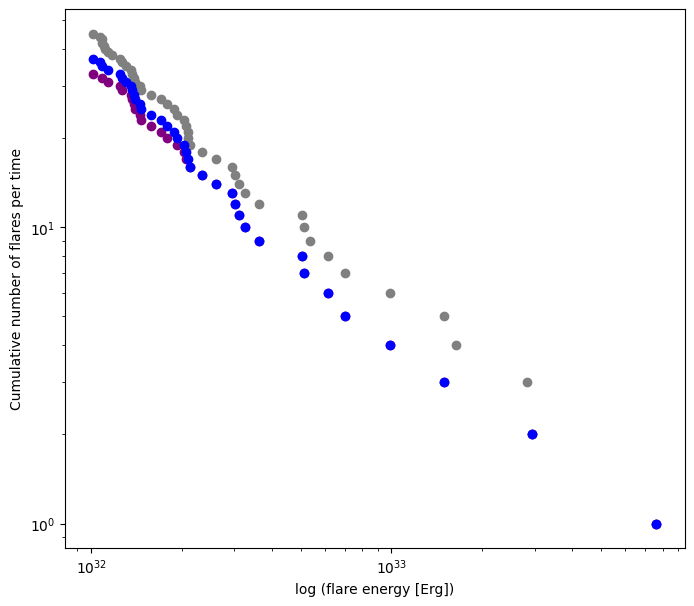

In [107]:
%matplotlib inline
plt.figure(figsize=(8, 7))

plt.scatter(ed3, freq3, c="gray", label = 'Setor 27 (20 segundos)')
plt.scatter(ed, freq, c="purple",label = 'Setor 1 (2 Min)')
plt.scatter(ed2, freq2, c="blue",label = 'Setor 27 (2 Min)')
#plt.scatter(ed3, freq3, c="gray")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("log (flare energy [Erg])")
plt.ylabel("Cumulative number of flares per time");


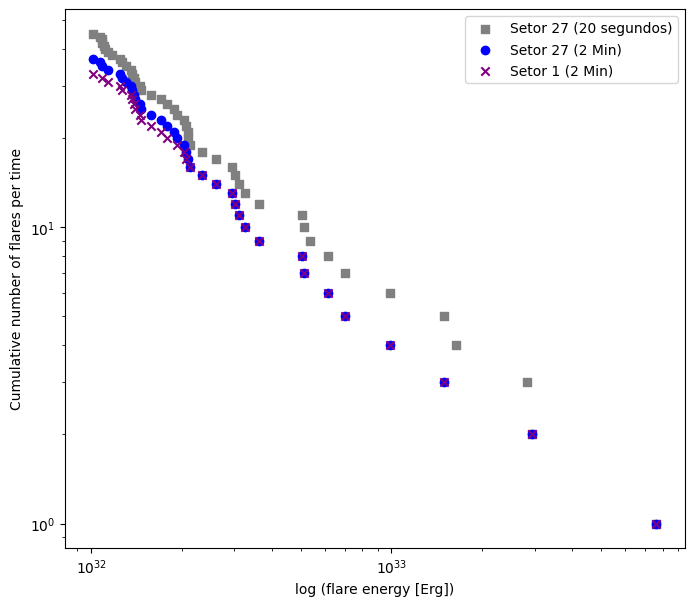

In [108]:
import matplotlib.pyplot as plt

# Seus dados para ed, freq, ed2, freq2, ed3 e freq3

plt.figure(figsize=(8, 7))

# Primeiro, plote o conjunto de dados de ed3 e freq3 (Setor 27 - 20 segundos)
plt.scatter(ed3, freq3, c="gray", label='Setor 27 (20 segundos)', marker='s')

# Em seguida, plote o conjunto de dados de ed2 e freq2 (Setor 27 - 2 Min)
plt.scatter(ed2, freq2, c="blue", label='Setor 27 (2 Min)',marker="o")

# Por último, plote o conjunto de dados de ed e freq (Setor 1 - 2 Min)
plt.scatter(ed, freq, c="purple", label='Setor 1 (2 Min)',marker="x")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("log (flare energy [Erg])")
plt.ylabel("Cumulative number of flares per time")

# Adicione a legenda
plt.legend()

# Exiba o gráfico
plt.show()
